**PART 1 : DATA EXPLORATION AND PREPARATION**

# Importing and loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Wholesale customers data.csv'

## Load the file
df = pd.read_csv(file_path)

print("File loaded successfully!")
print(df.head())

File loaded successfully!
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


# Basic information about the dataset

In [ ]:
df.info() ## Variable types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.shape ## Number of rows and columns

(440, 8)

In [ ]:
df.describe().T ## Descriptive statistics

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


# Check for missing values and duplicates

In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Dataset has no missing values or duplicate rows

# Univariate Exploratory Data Analysis

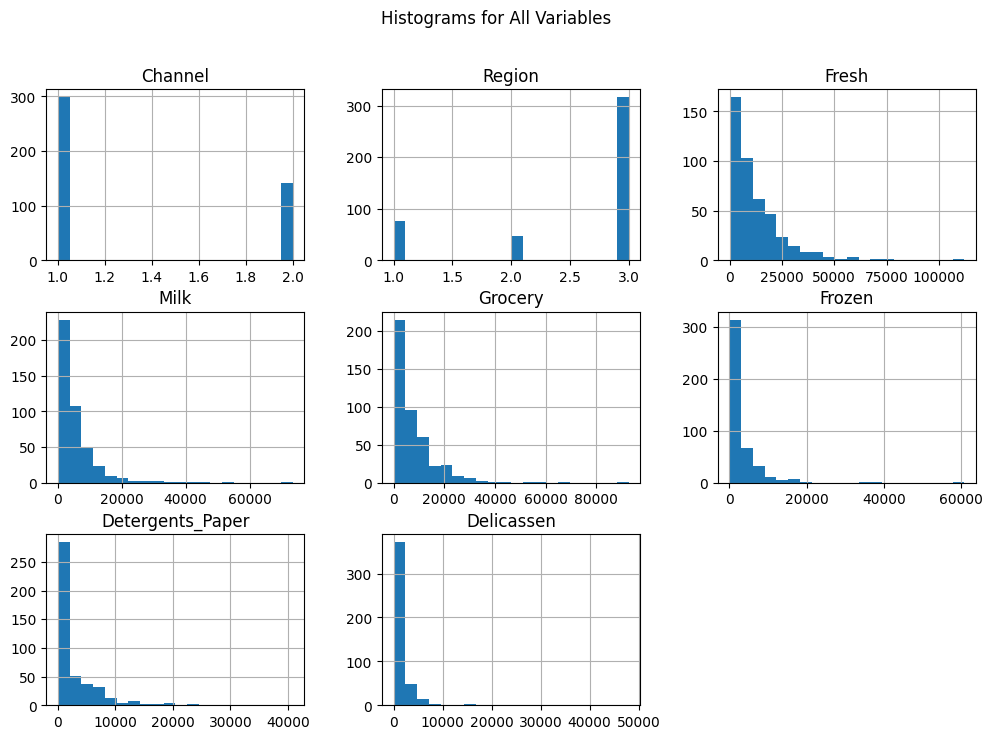

In [ ]:
## Histograms for all numerical variables

import matplotlib.pyplot as plt

df.hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms for All Variables")
plt.show()


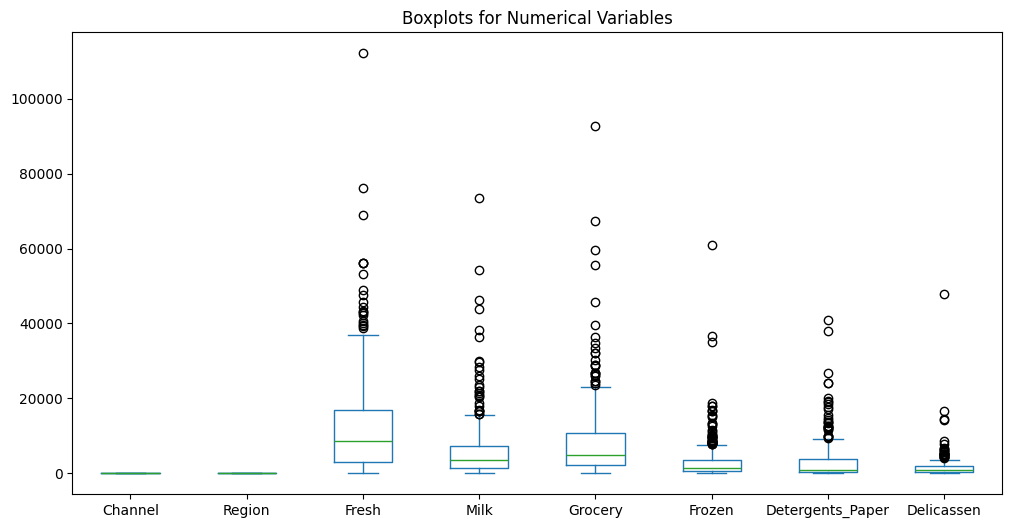

In [ ]:
## Boxplots to detect outliers

df.plot(kind='box', figsize=(12,6))
plt.title("Boxplots for Numerical Variables")
plt.show()


*  Distributions show strong positive (right) skewness
*  Boxplots show outliers in almost every spending category



# Pairwise relationships

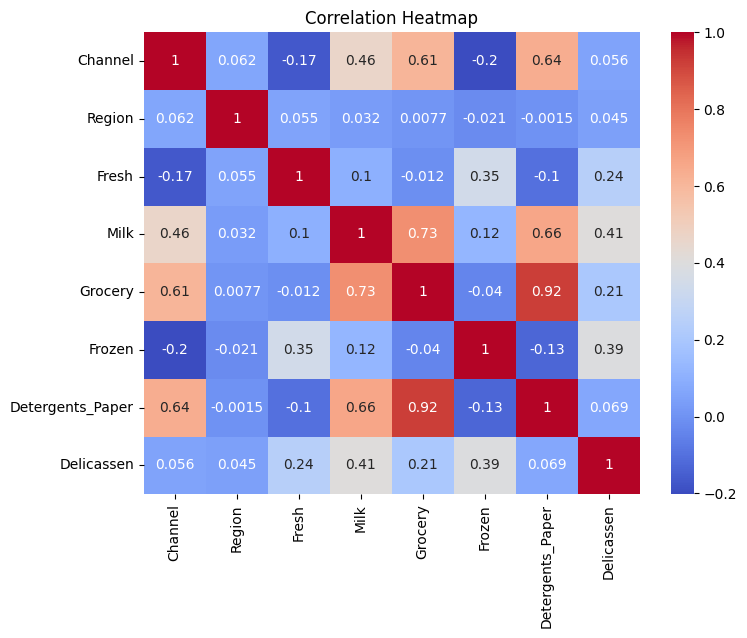

In [ ]:
## Correlation Matrix

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


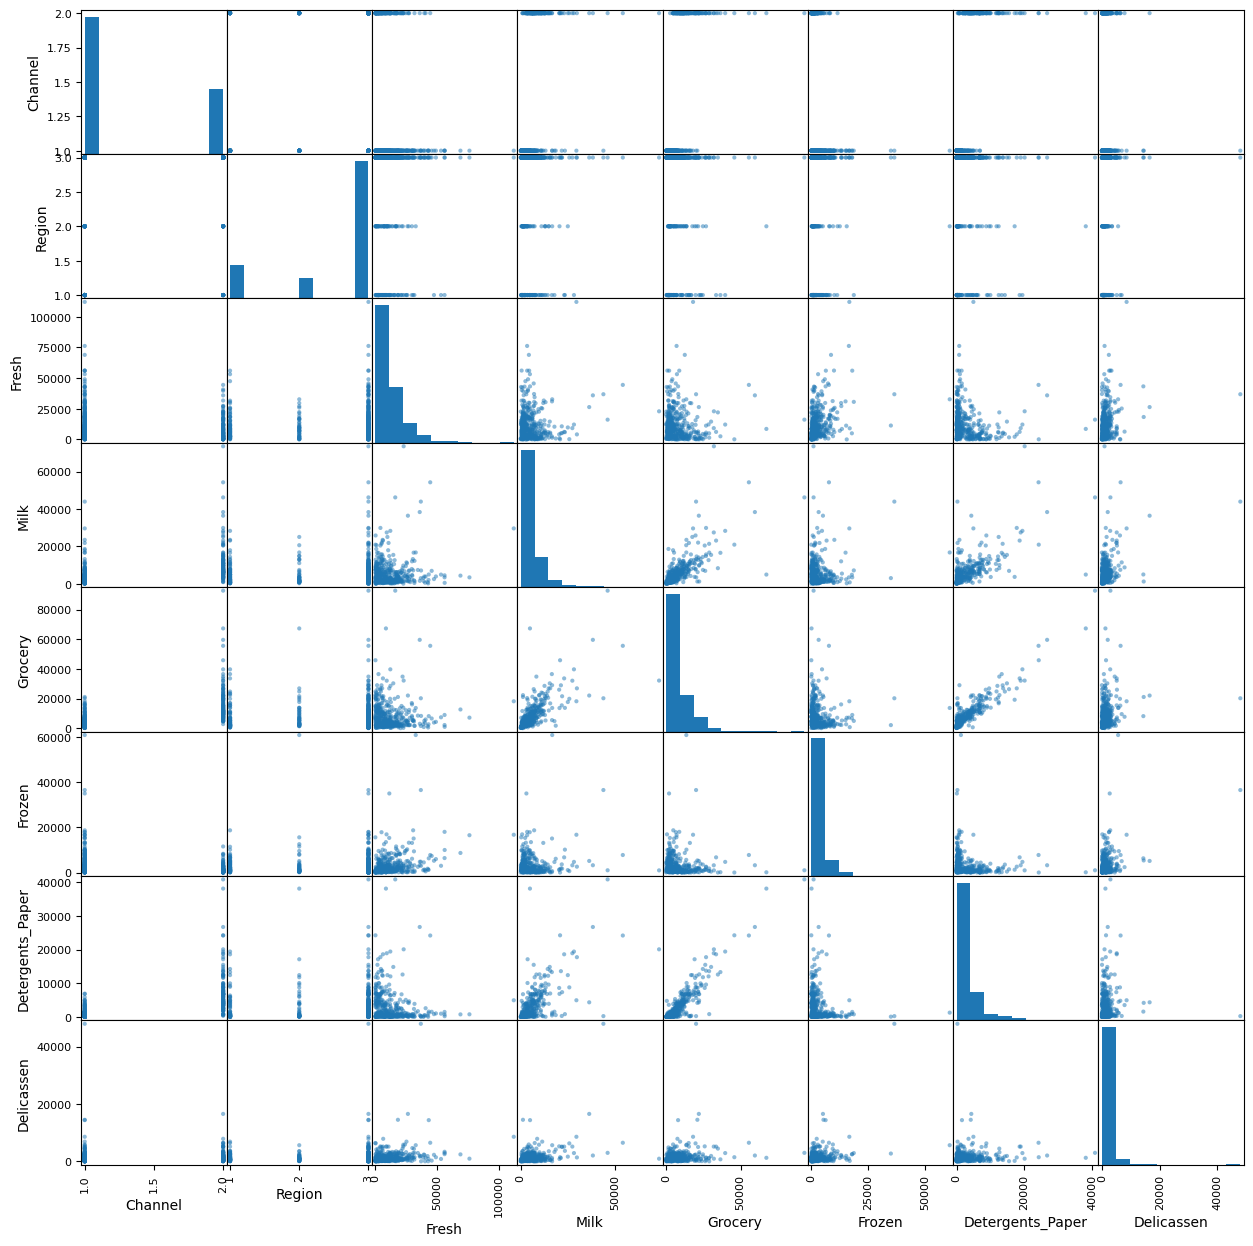

In [ ]:
## Scatter matrix

from pandas.plotting import scatter_matrix
scatter_matrix(df, figsize=(15,15), diagonal="hist")
plt.show()


*  Milk, Grocery, Detergents_Paper are strongly correlated.
*  Fresh, Frozen, Delicassen are weakly correlated with others.



# Outlier detection using Z-Score

In [ ]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df))
outliers = (z_scores > 3).sum(axis=0)
outliers


array([ 0,  0,  7,  9,  7,  6, 10,  4])

Outliers exist in the dataset, but we still keep them as the dataset is small and outliers are real purchasing behaviour.

# Overview of part 1

To begin the analysis, the Wholesale Customers Dataset was loaded and basic structural checks were performed. The dataset contains six spending categories, all of which are numeric. There were no missing values or duplicate entries, making the data relatively clean.

To better understand the distribution of each feature, histograms and boxplots were used. Most variables showed strong right-skewness, which is expected since customer spending can vary widely. Boxplots and Z-score analysis also revealed several outliers, but these outliers likely represent genuine high-spending customers. Therefore, they were intentionally retained rather than removed.

Correlation analysis revealed that Milk, Grocery, and Detergents_Paper are strongly related, suggesting these items may be purchased together frequently (e.g., by supermarkets or general stores). Meanwhile, Fresh, Frozen, and Delicassen showed weaker relationships with the other categories, indicating a different type of purchasing behavior.

Since all features are numerical, no categorical encoding was needed. Standardization was later applied for clustering to ensure all variables contribute equally to the model.

**PART 2 : MODEL DEVELOPMENT AND VALIDATION**

# Clustering Analysis

In [ ]:
## Select variables for clustering

num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
X = df[num_cols]


In [ ]:
## Standardize the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


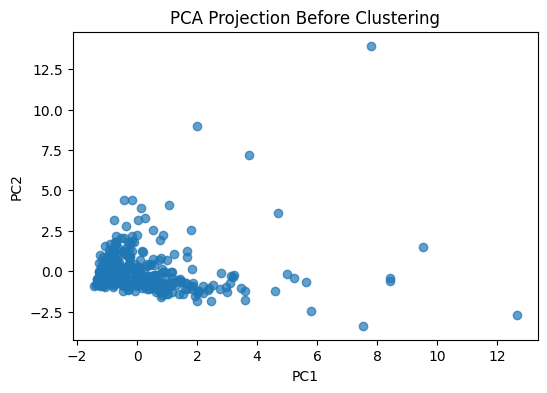

In [ ]:
## PCA for visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title("PCA Projection Before Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# Choose the number of cluster (k)

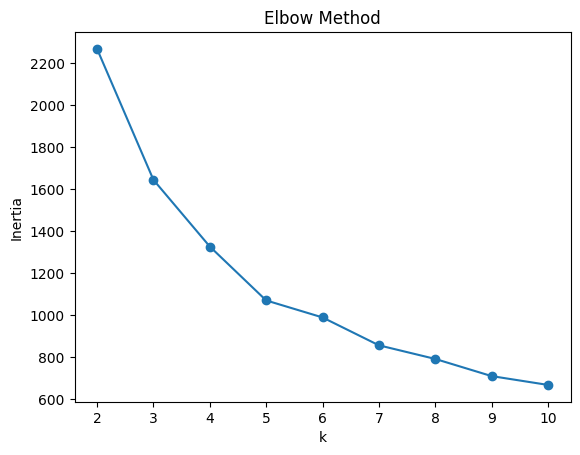

In [ ]:
## Elbow method

from sklearn.cluster import KMeans

inertia = []
K = range(2,11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


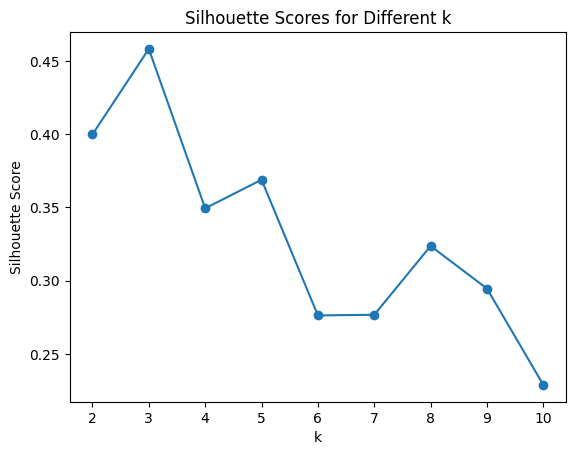

In [ ]:
## Silhouette score

from sklearn.metrics import silhouette_score

sil_scores = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.show()


# Evaluating the Optimal Number of Clusters

To determine how many clusters best represent the customers, two methods were used: the elbow method and silhouette analysis.

* The elbow curve showed a noticeable bend around
k = 3, indicating that adding more clusters beyond this point doesn’t significantly reduce inertia.

* The silhouette scores also peaked around k =3, suggesting that three clusters create the most cohesive and well-separated groups.

In addition to the elbow method and silhouette scores, clustering can also be evaluated using internal metrics such as the Calinski–Harabasz Index and the Davies–Bouldin Index.

For this analysis, I decided not to include these additional metrics because the combination of the elbow curve and silhouette analysis already provided a clear and consistent indication that k = 3 is the most appropriate number of clusters.

Since both methods independently suggested the same value of k, adding more metrics would not significantly change or strengthen the conclusion. Therefore, the silhouette and elbow methods were considered sufficient for selecting the optimal cluster count.


# K-means clustering (k=3)

In [ ]:
## Fit k-means with k=3

from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'].value_counts()


,count
Cluster,
0,350
1,53
2,37


We got the number of customers in each cluster

# PCA visualization of 3 clusters

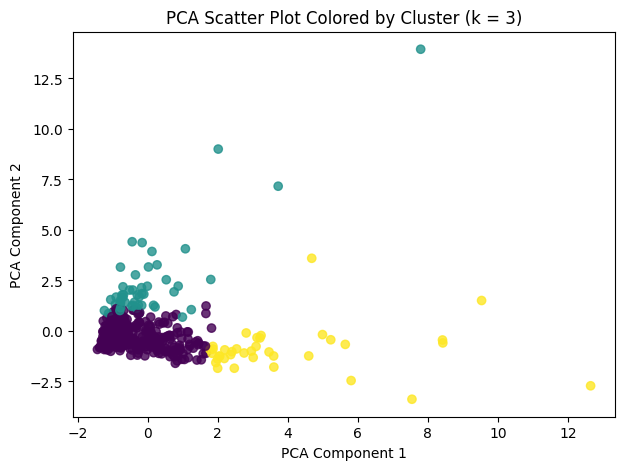

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', alpha=0.8)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot Colored by Cluster (k = 3)")
plt.show()


* Points with similar spending patterns are  grouped together.
* Colors indicate the 3 clusters.
* Well-separated clusters suggest that K-Means with k = 3 found distinct customer segments.

# Cluster centers

In [ ]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

cluster_centers = pd.DataFrame(centers_original, columns=num_cols)
cluster_centers.index = [f"Cluster {i}" for i in range(k)]
cluster_centers


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster 0,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000
Cluster 1,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283
Cluster 2,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351


* Cluster 0 : General buyers
* Cluster 1 : Focuses on fresh and frozen products.
* Cluster 2 : Focuses on bulk groceries, milk and detergents/paper products.  


# Detailed cluster profiles

In [ ]:
cluster_profiles = df.groupby('Cluster')[num_cols].mean().round(2)
cluster_profiles


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,8935.50,4228.53,5848.03,2167.23,1913.61,1102.12
1,34540.11,5860.36,6122.62,9841.74,981.47,3664.25
2,8704.86,20534.41,30466.24,1932.62,14758.84,2459.35


### **Interpreting the Customer Clusters**

After applying K-Means with k = 3, distinct groups emerged based on spending behaviors:

#### **Cluster 0 – Balanced/General Buyers**  
These customers show moderate spending across all product categories. They do not strongly specialize in any one area. This segment may include small retail shops or businesses with stable but moderate purchasing needs.

#### **Cluster 1 – Fresh and Frozen Product Buyers**  
This group spends heavily on Fresh and Frozen items compared to other features. These buyers may represent restaurants, hotels, or catering services that rely heavily on perishable goods.

#### **Cluster 2 – Grocery, Milk, and Detergents Heavy Buyers**  
Customers in this cluster spend significantly more on Grocery, Milk, and Detergents_Paper. This profile fits supermarkets, convenience stores, or wholesalers focused on large-volume household products.

These clusters show that customers differ not just in spending amount, but also in what they choose to buy. Understanding these differences can help businesses personalize their marketing and inventory strategies more effectively.

**PART 3 : INTERPRETATION AND INSIGHTS**

### **Key Insights from the Analysis**
The clustering analysis revealed three meaningful customer groups. One cluster consists of balanced buyers, another focuses mainly on fresh and frozen goods, and the third features customers who purchase high volumes of grocery-related items. The PCA visualization supported the fact that these customers behave differently in spending patterns. These findings confirm that meaningful and actionable customer segmentation is possible.

### **Business Implications**
These clusters can help wholesalers improve their decision-making:
- Fresh and frozen heavy customers (Cluster 1) may need frequent deliveries and temperature controlled storage solutions.  
- Grocery heavy customers (Cluster 2) may respond well to bulk discounts and loyalty incentives.  
- Balanced buyers (Cluster 0) could be ideal for cross selling campaigns since they don’t specialize.

By tailoring promotions, supply planning, and marketing to these groups, businesses can operate more efficiently.

### **Limitations**
- The dataset does not include demographic details, geographic information, or customer types, which limits deeper interpretation.  
- K-Means assumes spherical clusters and may not capture more complex structures.  
- Outliers were kept due to their real-world meaning, but they may still influence clustering results.

### **Recommendations for future work**
- Collect additional data such as customer segment (hotel, retailer, etc.) or location to enhance analysis.  
- Explore alternative clustering algorithms such as Hierarchical Clustering or DBSCAN.  
- Apply log-transformation to reduce skewness and see if cluster separation improves.  
- Study customer behavior over time if temporal data becomes available.